## **Regression Task -  Fuel Efficiency Prediction**

Libraries and Data Loading

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data (as pandas dataframes)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# metadata
print(auto_mpg.metadata)

# variable information
print(auto_mpg.variables)


{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

**Exploratory Data Analysis - EDA**

In [ ]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

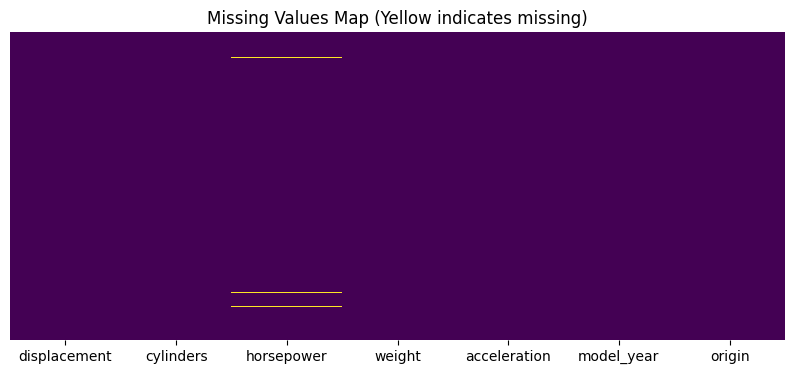

Missing values count per feature:
displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


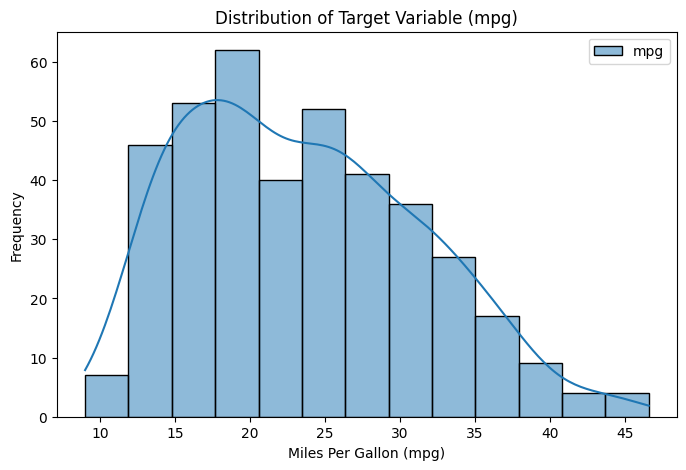

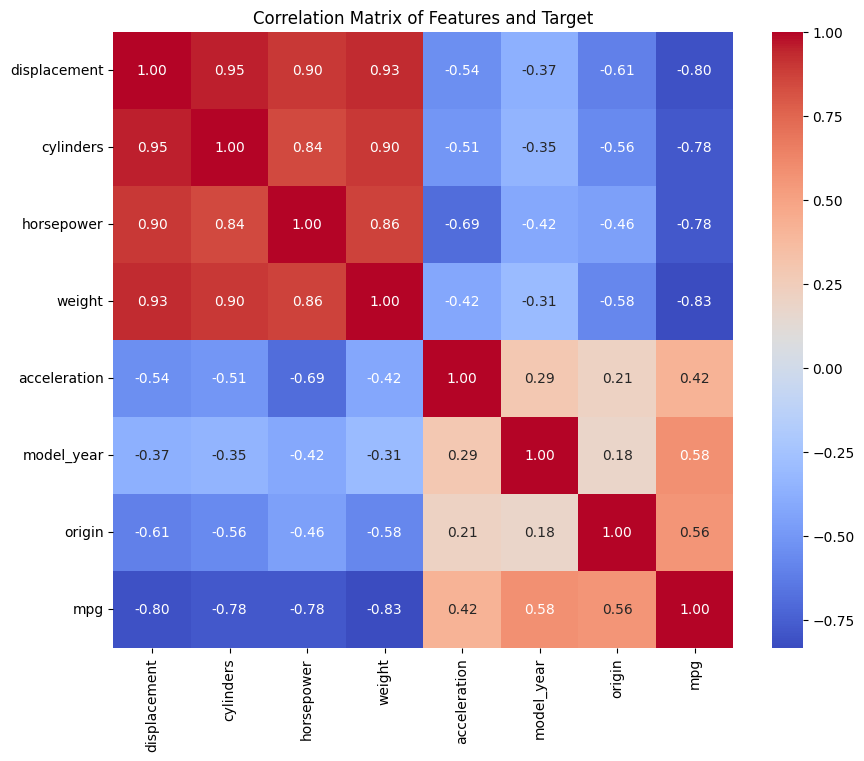

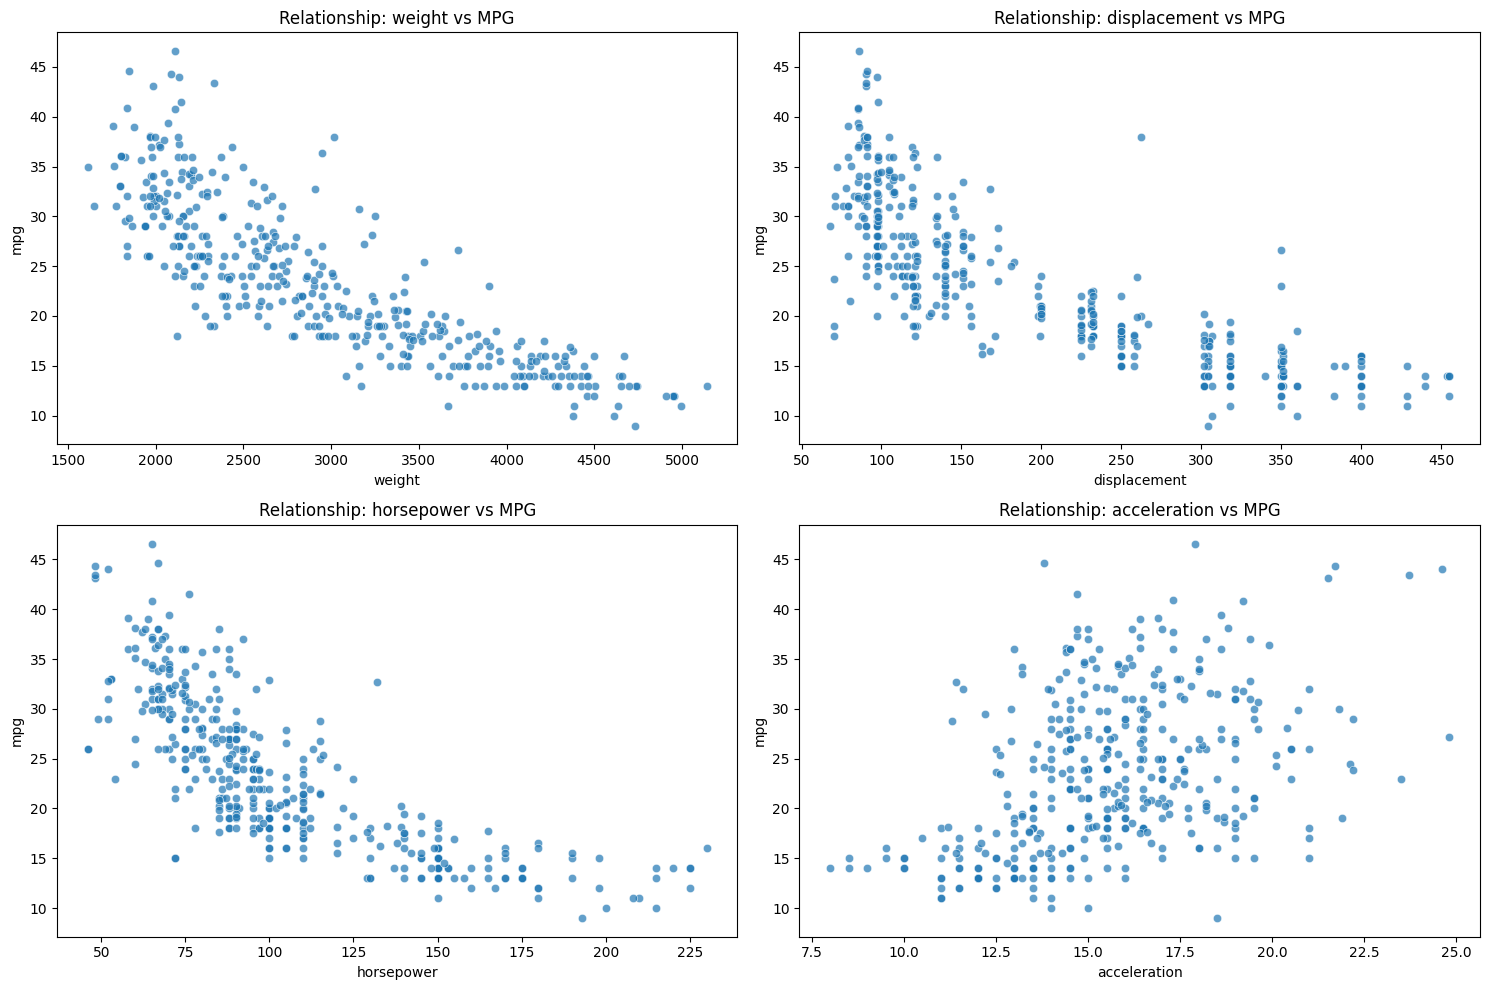

In [ ]:
# 1. Check for missing values with visualization
plt.figure(figsize=(10, 4))
sns.heatmap(X.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Map (Yellow indicates missing)')
plt.show()

print("Missing values count per feature:")
print(X.isnull().sum())

# 2. Distribution of the target variable (mpg)
plt.figure(figsize=(8, 5))
sns.histplot(y, kde=True, color='blue')
plt.title('Distribution of Target Variable (mpg)')
plt.xlabel('Miles Per Gallon (mpg)')
plt.ylabel('Frequency')
plt.show()

# 3. Correlation matrix (Correlations among features)
# Combine X and y for correlation analysis
full_df = pd.concat([X, y], axis=1)
plt.figure(figsize=(10, 8))
sns.heatmap(full_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features and Target')
plt.show()

# 4. Relationships between individual features and the target
# Choosing key continuous features to visualize against mpg
features_to_plot = ['weight', 'displacement', 'horsepower', 'acceleration']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(data=full_df, x=col, y='mpg', alpha=0.7)
    plt.title(f'Relationship: {col} vs MPG')

plt.tight_layout()
plt.show()

 **Dataset and Preprocessing**


In [ ]:
# Handle missing values in horsepower
df = pd.concat([X, y], axis=1)
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

# Separate features and target again
X = df.drop('mpg', axis=1)
y = df['mpg']

# Convert categorical data (origin) using One-Hot Encoding
X = pd.get_dummies(X, columns=['origin'], drop_first=True)

# Split the data into training and testing sets (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete. Data is scaled and split.")

Preprocessing complete. Data is scaled and split.


**Linear Regression Baseline**

Linear Regression Metrics:
MSE: 8.3387
RMSE: 2.8877
MAE: 2.2882
R2 Score: 0.8449


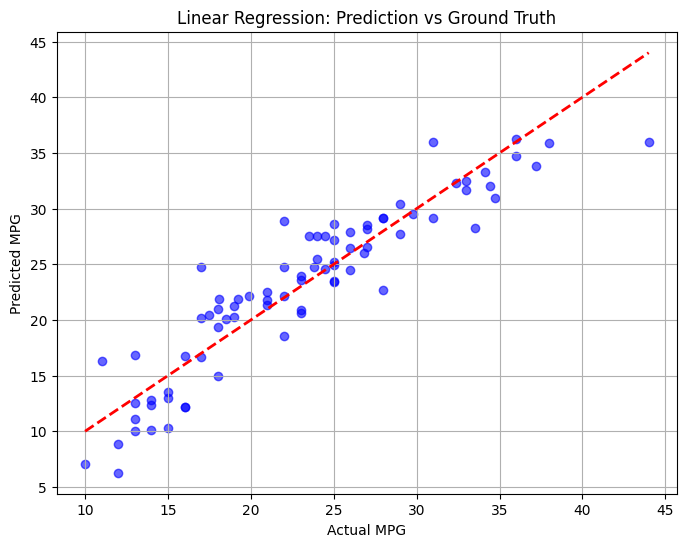

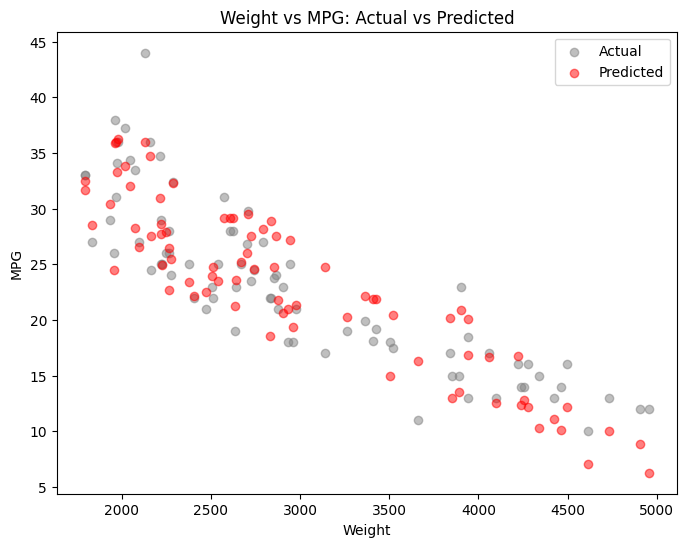

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Train the model
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# 2. Predictions
y_pred = lin_reg.predict(X_test_scaled)

# 3. Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Metrics:\n"
      f"MSE: {mse:.4f}\n"
      f"RMSE: {rmse:.4f}\n"
      f"MAE: {mae:.4f}\n"
      f"R2 Score: {r2:.4f}")

# 4. Required Figure: Prediction vs Ground Truth
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Prediction vs Ground Truth')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.grid(True)
plt.show()

# 5. Required Figure: Feature-Target Relationship (e.g., Weight vs MPG)
# Using unscaled X_test for clearer axis labels in the plot
plt.figure(figsize=(8, 6))
plt.scatter(X_test['weight'], y_test, color='gray', label='Actual', alpha=0.5)
plt.scatter(X_test['weight'], y_pred, color='red', label='Predicted', alpha=0.5)
plt.title('Weight vs MPG: Actual vs Predicted')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.legend()
plt.show()

**Polynomial Regression**

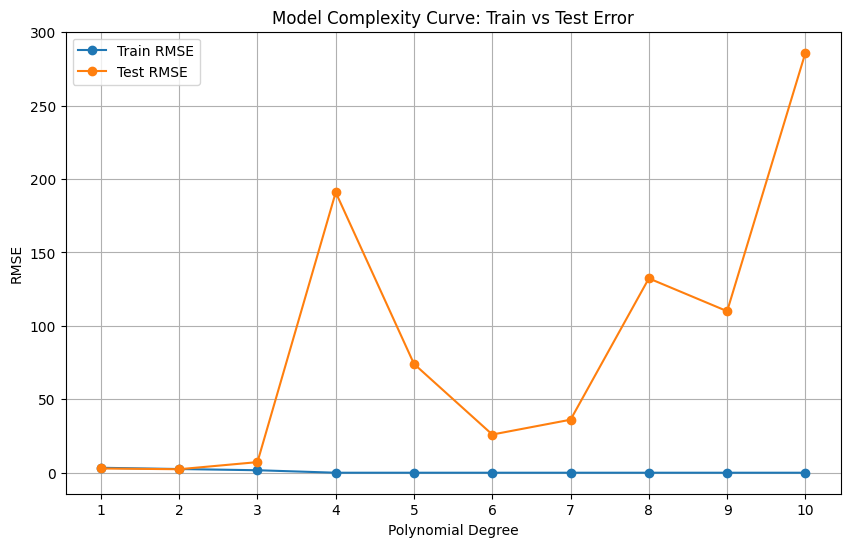

The best polynomial degree is: 2
Minimum Test RMSE: 2.3804


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degrees = range(1, 11)
train_rmse_list = []
test_rmse_list = []

for degree in degrees:
    # Create a pipeline: Polynomial Features -> Linear Regression
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train_scaled, y_train)

    # Predict and calculate RMSE
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_rmse_list.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    test_rmse_list.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

# Required Figure: Model Complexity Curve
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_rmse_list, label='Train RMSE', marker='o')
plt.plot(degrees, test_rmse_list, label='Test RMSE', marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Model Complexity Curve: Train vs Test Error')
plt.xticks(degrees)
plt.legend()
plt.grid(True)
plt.show()

# Find the best degree (minimum Test RMSE)
best_degree = degrees[np.argmin(test_rmse_list)]
print(f"The best polynomial degree is: {best_degree}")
print(f"Minimum Test RMSE: {min(test_rmse_list):.4f}")

**KNN Regression**

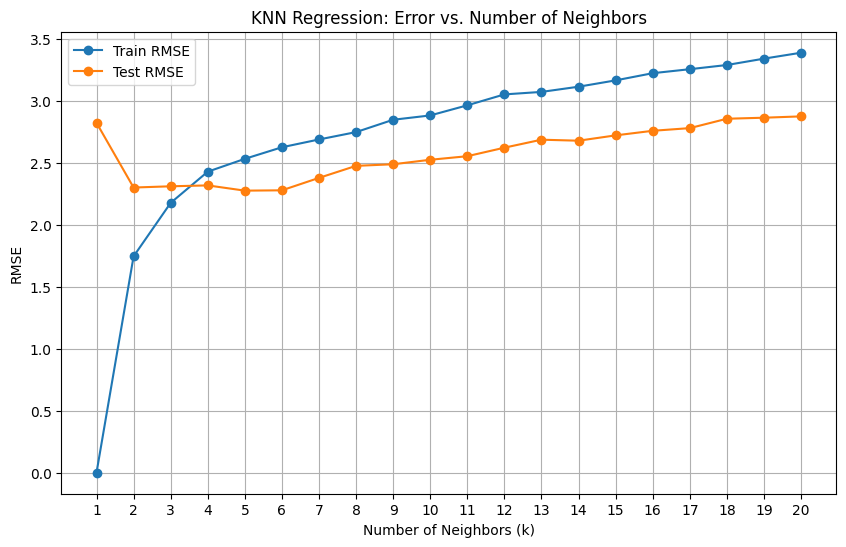

The best k value is: 5


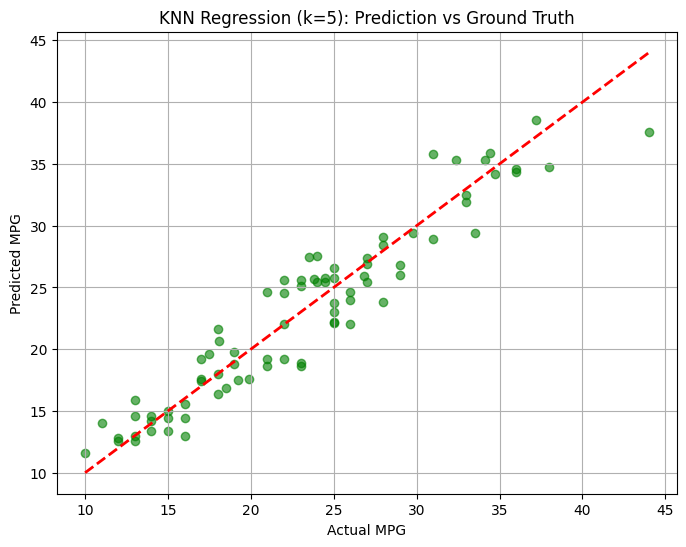

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

k_values = range(1, 21)
knn_train_rmse = []
knn_test_rmse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Predictions
    y_knn_train_pred = knn.predict(X_train_scaled)
    y_knn_test_pred = knn.predict(X_test_scaled)

    knn_train_rmse.append(np.sqrt(mean_squared_error(y_train, y_knn_train_pred)))
    knn_test_rmse.append(np.sqrt(mean_squared_error(y_test, y_knn_test_pred)))

# Required Figure 1: Train/Test Error vs. K
plt.figure(figsize=(10, 6))
plt.plot(k_values, knn_train_rmse, label='Train RMSE', marker='o')
plt.plot(k_values, knn_test_rmse, label='Test RMSE', marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('RMSE')
plt.title('KNN Regression: Error vs. Number of Neighbors')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

# Find best k
best_k = k_values[np.argmin(knn_test_rmse)]
print(f"The best k value is: {best_k}")

# Required Figure 2: Prediction vs Ground Truth for Best K
best_knn = KNeighborsRegressor(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
y_knn_best_pred = best_knn.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_knn_best_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'KNN Regression (k={best_k}): Prediction vs Ground Truth')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.grid(True)
plt.show()

**Optimization Behavior**

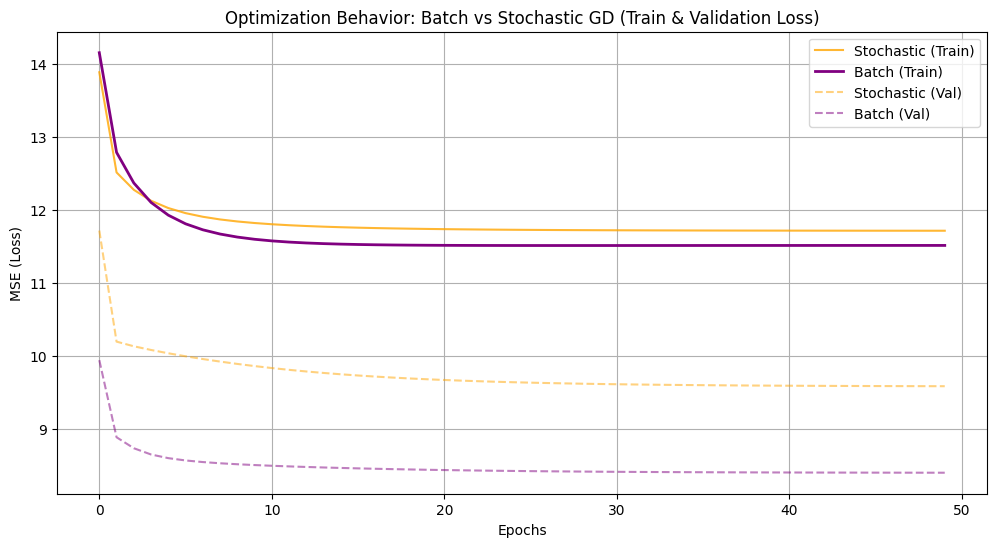

Final Batch Test MSE: 8.4055
Final Stochastic Test MSE: 9.5883


In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Define identical learning rate for fair comparison
eta_value = 0.01
epochs = 50

# Initialize both strategies
# Using max_iter=1 and warm_start=True to manually control the iterations (epochs)
sgd_stochastic = SGDRegressor(learning_rate='constant', eta0=eta_value, max_iter=1, warm_start=True, random_state=42)
sgd_batch = SGDRegressor(learning_rate='constant', eta0=eta_value, max_iter=1, warm_start=True, random_state=42)

# Lists to store training and validation loss for both methods
loss_stochastic_train = []
loss_stochastic_val = []
loss_batch_train = []
loss_batch_val = []

for i in range(epochs):
    # 1. Stochastic Gradient Descent: Update weights after EVERY single sample
    for j in range(len(X_train_scaled)):
        sgd_stochastic.partial_fit(X_train_scaled[j:j+1], y_train.iloc[j:j+1])

    # 2. Batch Gradient Descent: Update weights ONCE per epoch using the whole set
    sgd_batch.partial_fit(X_train_scaled, y_train)

    # Record MSE for training data
    loss_stochastic_train.append(mean_squared_error(y_train, sgd_stochastic.predict(X_train_scaled)))
    loss_batch_train.append(mean_squared_error(y_train, sgd_batch.predict(X_train_scaled)))

    # Record MSE for validation data (Required for the assignment)
    loss_stochastic_val.append(mean_squared_error(y_test, sgd_stochastic.predict(X_test_scaled)))
    loss_batch_val.append(mean_squared_error(y_test, sgd_batch.predict(X_test_scaled)))

# Plotting the results
plt.figure(figsize=(12, 6))

# Plot training curves (solid lines)
plt.plot(range(epochs), loss_stochastic_train, label='Stochastic (Train)', color='orange', alpha=0.8)
plt.plot(range(epochs), loss_batch_train, label='Batch (Train)', color='purple', linewidth=2)

# Plot validation curves (dashed lines)
plt.plot(range(epochs), loss_stochastic_val, '--', label='Stochastic (Val)', color='orange', alpha=0.5)
plt.plot(range(epochs), loss_batch_val, '--', label='Batch (Val)', color='purple', alpha=0.5)

plt.xlabel('Epochs')
plt.ylabel('MSE (Loss)')
plt.title('Optimization Behavior: Batch vs Stochastic GD (Train & Validation Loss)')
plt.legend()
plt.grid(True)
plt.show()

# Print final results for the discussion
print(f"Final Batch Test MSE: {loss_batch_val[-1]:.4f}")
print(f"Final Stochastic Test MSE: {loss_stochastic_val[-1]:.4f}")

**Model Comparison and Discussion**

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Define the best polynomial model directly (Degree 2)
best_poly = make_pipeline(PolynomialFeatures(2), LinearRegression())
best_poly.fit(X_train_scaled, y_train)
y_poly_pred = best_poly.predict(X_test_scaled)

# 2. Prepare the summary data
models_summary = {
    "Model Type": [
        "Linear Regression",
        "Polynomial Regression (Degree 2)",
        "KNN Regression (k=5)"
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)), # From section 2.3
        np.sqrt(mean_squared_error(y_test, y_poly_pred)), # Fixed for Degree 2
        np.sqrt(mean_squared_error(y_test, y_knn_best_pred)) # From section 2.5
    ],
    "Test R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_poly_pred), # Fixed for Degree 2
        r2_score(y_test, y_knn_best_pred)
    ]
}

# 3. Create and display the summary table
summary_df = pd.DataFrame(models_summary)
print("Final Comparison of Regression Models:")
display(summary_df)

# Final step: Identify the best model based on the lowest RMSE
best_overall_model_name = summary_df.loc[summary_df['Test RMSE'].idxmin(), 'Model Type']
print(f"\nConclusion: The best model for deployment is {best_overall_model_name}")

Final Comparison of Regression Models:


,Model Type,Test RMSE,Test R2 Score
0,Linear Regression,2.887673,0.844910
1,Polynomial Regression (Degree 2),2.380433,0.894610
2,KNN Regression (k=5),2.276328,0.903626



Conclusion: The best model for deployment is KNN Regression (k=5)
